In [1]:
# Import core libraries and NUGGET modules
import torch
import numpy as np
import nugget  # Main NUGGET package for neutrino detector optimization
import matplotlib.pyplot as plt
import importlib
import pickle
import pandas as pd
import plotly.express as px
import time
from nugget.losses.effective_area import get_bounding_cylinder
from IPython.display import clear_output

In [2]:
importlib.reload(nugget.samplers.cyl_sampler)
# Create a skewed Gaussian surrogate for light yield prediction
# Skewedgauss = nugget.surrogates.SkewedGaussian.SkewedGaussian(sigma_factor=6) 
# light_yield_surrogate = Skewedgauss.light_yield_surrogate
lightsabre_surrogate = nugget.surrogates.LightSabre.LightSabre()
light_yield_surrogate = lightsabre_surrogate.light_yield_surrogate
# light_yield_surrogate = nugget.surrogates.Uniform.Uniform()
# Initialize event samplers for signal and background events
signal_sampler = nugget.samplers.cyl_sampler.CylinderSampler(event_type='signal', domain_size=2500, E_min=1e6, E_max=1e8, cylinder_radius=500, cylinder_height=1000)
# signal_sampler = nugget.samplers.toy_sampler.ToySampler(x_bias=0, event_type='signal', domain_size=2500, E_min=1e6, E_max=1e8)
# background_sampler = nugget.samplers.toy_sampler.ToySampler(x_bias=0, event_type='background', domain_size=2500, E_min=1e6, E_max=1e8)

/ptmp/mpp/kristcho/nugget/nugget/samplers/cyl_sampler.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.center = torch.tensor(center)


In [3]:
test_signal_events = signal_sampler.sample_events(10000)

In [4]:
test_signal_events[0]

{'position': [tensor([ 125.5590,  163.2287, -316.8053])],
 'direction': tensor([ 0.5515, -0.8101, -0.1988]),
 'energy': tensor([5012437.5000]),
 'zenith': tensor([1.7709]),
 'azimuth': tensor([-0.9731])}

In [3]:
importlib.reload(nugget.losses.fisher_info)
importlib.reload(nugget.losses.trigger)
importlib.reload(nugget.losses.geometry_penalties)
# Light Yield Loss: Maximizes total light collected by detector
signal_yield_loss_func = nugget.losses.light_yield.LightYieldLoss(
    # device=geometry.device,
)

# === GEOMETRY PENALTY FUNCTIONS ===
# These prevent unphysical detector configurations

# Local String Repulsion: Prevents strings from getting too close to each other
local_repulsion_penalty = nugget.losses.geometry_penalties.LocalRepulsionPenalty(
    # device=geometry.device
)

# === RESOLUTION-BASED LOSSES ===
# Angular Resolution: Optimizes detector's ability to reconstruct particle direction
angular_resolution_loss = nugget.losses.fisher_info.ResolutionLoss(
    # device=geometry.device,
    resolution_type='angular'
)

# Energy Resolution: Optimizes detector's ability to reconstruct particle energy
energy_resolution_loss = nugget.losses.fisher_info.ResolutionLoss(
    # device=geometry.device,
    resolution_type='energy'
)

# ROV Penalty: Accounts for physical constraints from Remotely Operated Vehicle
rov_penalty = nugget.losses.geometry_penalties.ROVPenalty(
    # device=geometry.device, 
    rov_rec_width=240,  # ROV dimensions
    rov_height=160, 
    rov_tri_length=160
)

trigger_loss = nugget.losses.trigger.TriggerLoss(
    light_yield_threshold=6,
    min_pairs_threshold=29,
    pairwise_distance_threshold=550,
    t1_temperature=1,
    t2_temperature=1,
    t3_temperature=1,
    t_temperature=10,  
)


/tmp/ipykernel_394582/2328990039.py:24: DeprecationWarning:

__array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)



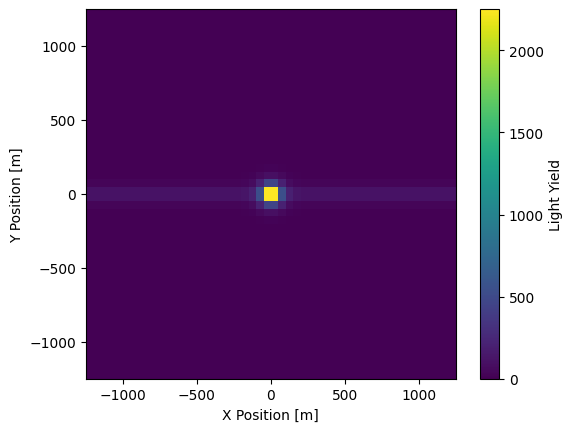

In [ ]:
test_signal_events = signal_sampler.sample_events(2)  # Fresh signal events for optimization
# new_background_events = background_sampler.sample_events(2)  # Fresh background events
domain_size = 2500
half_size = domain_size / 2
steps = 50
x = np.linspace(-half_size, half_size, steps)
y = np.linspace(-half_size, half_size, steps)
z = np.linspace(-half_size, half_size, steps)
X, Y, Z = np.meshgrid(x, y, z)
points = np.vstack([X.ravel(), Y.ravel(), Z.ravel()]).T
points = torch.tensor(points, dtype=torch.float32)
ly = torch.zeros((points.shape[0],))
for i, event_params in enumerate(test_signal_events):
    # # event_params['energy'] = torch.tensor([1e6])
    event_params['position'] = torch.tensor([0,0,0])
    
    if i == 0:
        event_params['azimuth'] = torch.tensor([torch.pi])
        event_params['zenith'] = torch.tensor([torch.pi / 2])
    if i == 1:
        event_params['azimuth'] = torch.tensor([torch.pi])
        event_params['zenith'] = torch.tensor([torch.pi])
    event_params['energy'] = torch.tensor(1e5)
    ly += light_yield_surrogate(opt_point=points, event_params=event_params).numpy()
ly = ly / len(test_signal_events)
ly_reshaped = ly.numpy().reshape((steps, steps, steps))
# then take the average across z axis
avg_ly = np.sum(ly_reshaped, axis=2)
plt.imshow(avg_ly, extent=(-half_size, half_size, -half_size, half_size), cmap='viridis')
plt.xlabel('X Position [m]')
plt.ylabel('Y Position [m]')
plt.colorbar(label='Light Yield')

(-300.0, 300.0)

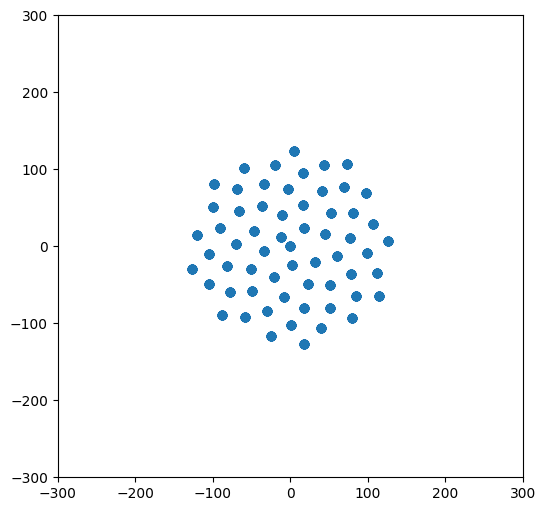

In [2]:
importlib.reload(nugget.geometries)
importlib.reload(nugget.geometries.base_geometry)
importlib.reload(nugget.geometries.SpaceString)


trigger_loss = nugget.losses.trigger.TriggerLoss(
    light_yield_threshold=6,
    min_pairs_threshold=29,
    pairwise_distance_threshold=550,
    t1_temperature=1,
    t2_temperature=1,
    t3_temperature=1,
    t_temperature=100,  
)
string_spacing = 17  # Spacing between strings in the hexagonal grid
z_spacing = 110  # Spacing between points along each string
geometry = nugget.geometries.SpaceString.SpaceString(
            hex_type='sunflower',
            domain_size=2500,  # Size of detector domain
            # device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'),  # Use GPU if available
            dim=3,  # 3D geometry
            n_strings=61,  # Initial number of detector strings
            points_per_string=20,  # Number of PMTs/sensors per string
            # starting_weight=-0.5,  # Initial weight for each string (controls visibility)
            # custom_string_spacing=0.09  # Custom spacing between strings
            starting_spacing=string_spacing,
            starting_z_spacing=z_spacing,
            hybrid_mix_init=0.8,
            hybrid_iter_step=0.005
        )
geom_dict = geometry.initialize_points()
points_3d = geom_dict['points_3d']
# dists_sq = points_3d.unsqueeze(0).numpy() - points_3d.unsqueeze(1).numpy()
# dists = np.sqrt(np.sum(dists_sq**2, axis=-1))
# print(f"Min distance between points: {np.min(dists[dists>0])}")
# loss_params = {
#     'max_radius': 80,
#     'signal_event_params': test_signal_events,   
#     'signal_surrogate_func': light_yield_surrogate,  # Function to compute light yield
# }
# trigger_loss(geom_dict, **loss_params)['detector_efficiency'].item()
plt.figure(figsize=(6, 6))
plt.scatter(points_3d[:, 0].cpu(), points_3d[:, 1].cpu())
plt.xlim(-300, 300)
plt.ylim(-300, 300)

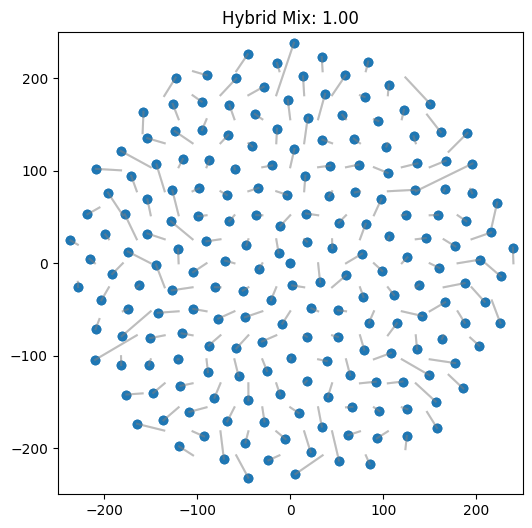

In [9]:
string_spacing = 30  # Spacing between strings in the hexagonal grid
z_spacing = 110  # Spacing between points along each string
points_history = []
for hybrid_mix in np.linspace(0, 1, 20):    
    # update the shown plot with new geometry
# hybrid_mix = 1
    geometry = nugget.geometries.SpaceString.SpaceString(
                hex_type='hybrid',
                domain_size=1100,  # Size of detector domain
                # device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'),  # Use GPU if available
                dim=3,  # 3D geometry
                n_strings=200,  # Initial number of detector strings
                points_per_string=2,  # Number of PMTs/sensors per string
                # starting_weight=-0.5,  # Initial weight for each string (controls visibility)
                # custom_string_spacing=0.09  # Custom spacing between strings
                starting_spacing=string_spacing,
                # starting_z_spacing=z_spacing,
                hybrid_mix_init=hybrid_mix,
                hybrid_iter_step=0.01
            )
    geom_dict = geometry.initialize_points()
    points_3d = geom_dict['points_3d']
    points_history.append(points_3d.cpu().numpy())
    # draw curve showing the trajection of each point from points history
    clear_output(wait=True)
    plt.figure(figsize=(6, 6))
    plt.scatter(geom_dict['points_3d'][:,0].cpu(), geom_dict['points_3d'][:,1].cpu())
    for i in range(points_3d.shape[0]):
        history = np.array([points_history[j][i] for j in range(len(points_history))])
        plt.plot(history[:,0], history[:,1], color='gray', alpha=0.3)
    plt.title(f"Hybrid Mix: {hybrid_mix:.2f}")
    plt.xlim(-250, 250)
    plt.ylim(-250, 250)
    plt.show()
    time.sleep(0.1)

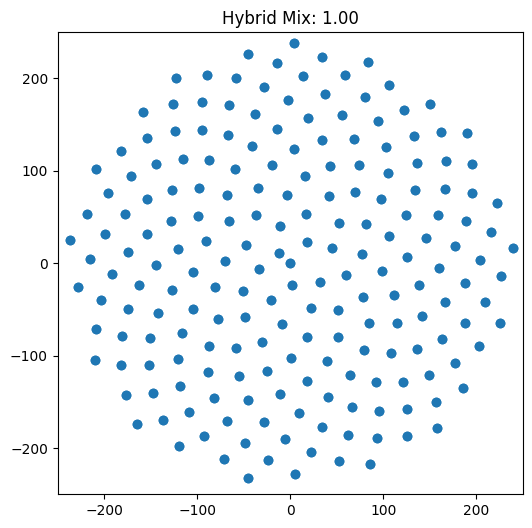

Animation saved as hybrid_mix_animation.gif


In [5]:
from matplotlib.animation import FuncAnimation, PillowWriter

import matplotlib.pyplot as plt

string_spacing = 30  # Spacing between strings in the hexagonal grid
z_spacing = 30  # Spacing between points along each string

fig, ax = plt.subplots(figsize=(6, 6))
frames = []

for hybrid_mix in np.linspace(0, 1, 40):    
    # update the shown plot with new geometry
    geometry = nugget.geometries.SpaceString.SpaceString(
                hex_type='hybrid',
                domain_size=1100,  # Size of detector domain
                # device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'),  # Use GPU if available
                dim=3,  # 3D geometry
                n_strings=200,  # Initial number of detector strings
                points_per_string=2,  # Number of PMTs/sensors per string
                # starting_weight=-0.5,  # Initial weight for each string (controls visibility)
                # custom_string_spacing=0.09  # Custom spacing between strings
                starting_spacing=string_spacing,
                starting_z_spacing=z_spacing,
                hybrid_mix_init=hybrid_mix,
            )
    geom_dict = geometry.initialize_points()
    points_3d = geom_dict['points_3d']
    
    # Store frame data
    frames.append((geom_dict['points_3d'][:,0].cpu().numpy(), 
                   geom_dict['points_3d'][:,1].cpu().numpy(), 
                   hybrid_mix))
    
    clear_output(wait=True)
    ax.clear()
    ax.scatter(geom_dict['points_3d'][:,0].cpu(), geom_dict['points_3d'][:,1].cpu())
    ax.set_title(f"Hybrid Mix: {hybrid_mix:.2f}")
    ax.set_xlim(-250, 250)
    ax.set_ylim(-250, 250)
    # plt.pause(0.1)

# Create animation and save as GIF
def update(frame_idx):
    ax.clear()
    x_data, y_data, mix = frames[frame_idx]
    ax.scatter(x_data, y_data)
    ax.set_title(f"Hybrid Mix: {mix:.2f}")
    ax.set_xlim(-250, 250)
    ax.set_ylim(-250, 250)
    return ax,

anim = FuncAnimation(fig, update, frames=len(frames), interval=100, blit=False)
writer = PillowWriter(fps=10)
anim.save('hybrid_mix_animation.gif', writer=writer)
plt.show()
print("Animation saved as hybrid_mix_animation.gif")

In [7]:
# new_signal_events = signal_sampler.sample_events(100)  # Fresh signal events for optimization
# new_background_events = background_sampler.sample_events(100)  # Fresh background events
test_num = 30
signal_yield_losses = np.zeros((test_num, test_num))
rov_penalty_losses = np.zeros((test_num, test_num))
local_repulsion_penalty_losses = np.zeros((test_num, test_num))
energy_resolution_losses = np.zeros((test_num, test_num))
angular_resolution_losses = np.zeros((test_num, test_num))
trigger_losses = np.zeros((test_num, test_num))
detector_efficiencies = np.zeros((test_num, test_num))
radii = []
heights = []
centers = []
min_space = 50
max_space = 500
for i, z_spacing in enumerate(np.linspace(min_space, max_space, test_num)):  # Range of z_spacing values to test
    for j, string_spacing in enumerate(np.linspace(min_space, max_space, test_num)):  # Range of string_spacing values to test
        

        # geometry = nugget.geometries.EvanescentString.EvanescentString(
        geometry = nugget.geometries.SpaceString.SpaceString(
            hex_type='hexagonal',
            domain_size=2500,  # Size of detector domain
            # device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'),  # Use GPU if available
            dim=3,  # 3D geometry
            n_strings=70,  # Initial number of detector strings
            points_per_string=20,  # Number of PMTs/sensors per string
            # starting_weight=-0.5,  # Initial weight for each string (controls visibility)
            # custom_string_spacing=0.09  # Custom spacing between strings
            starting_spacing=string_spacing,
            starting_z_spacing=z_spacing
        )
        geom_dict = geometry.initialize_points()
        cyl_center, cyl_radius, cyl_height = get_bounding_cylinder(geom_dict['points_3d'])
        signal_sampler = nugget.samplers.cyl_sampler.CylinderSampler(event_type='signal', 
                                        domain_size=2500, E_min=1e6, E_max=1e8, cylinder_center=cyl_center, 
                                        cylinder_radius=cyl_radius, cylinder_height=cyl_height)
        radii.append(cyl_radius)
        heights.append(cyl_height)
        centers.append(cyl_center)
        new_signal_events = signal_sampler.sample_events(100)  # Fresh signal events for optimization
        loss_params = {
        # 'llr_net': llr_net,
        'signal_event_params': new_signal_events,   
        # 'background_event_params': new_background_events,
        'signal_surrogate_func': light_yield_surrogate,  # Function to compute light yield
        # 'background_surrogate_func': light_yield_surrogate,
        'signal_sampler': signal_sampler,
        # 'background_sampler': background_sampler,
        'num_events': 1,  # Number of events to sample per optimization step
        'signal_noise_scale': 0.0,  # Noise level for signal events
        'background_noise_scale': 0.2,  # Noise level for background events
        'boundary_range': 2,  # Size of boundary region
        'eva_min_num_strings': 10,  # Minimum number of active strings
        'max_radius': 80,  # Maximum radius for string placement
        'num_angles': 12,  # Number of angles (divided into 360 degrees) to test for rov
        'local_sharpness': 10,  # Sharpness parameter for local string repulsion
        'string_number_beta':100,
        }
        precomputed_fisher_info_per_event = angular_resolution_loss.compute_fisher_info_per_event(
                # string_xy=geom_dict['string_xy'],
                points_3d=geom_dict['points_3d'],
                event_params=new_signal_events,
                surrogate_func=light_yield_surrogate,
            )
    
        loss_params['precomputed_fisher_info_per_event'] = precomputed_fisher_info_per_event
        signal_yield_losses[i, j] = signal_yield_loss_func(geom_dict, **loss_params)['signal_yield_loss'].item()
        rov_penalty_losses[i, j] = rov_penalty(geom_dict, **loss_params)['rov_penalty'].item()
        local_repulsion_penalty_losses[i, j] = local_repulsion_penalty(geom_dict, **loss_params)['local_repulsion_penalty'].item()
        energy_resolution_losses[i,j] = energy_resolution_loss(geom_dict, **loss_params)['energy_resolution_loss'].item()
        angular_resolution_losses[i, j] = angular_resolution_loss(geom_dict, **loss_params)['angular_resolution_loss'].item()*np.pi
        trigger_stuff = trigger_loss(geom_dict, **loss_params)
        trigger_losses[i, j] = trigger_stuff['trigger_loss'].item()
        detector_efficiencies[i, j] = trigger_stuff['detector_efficiency'].item()
        print(f"Completed ({i+1}, {j+1}) out of ({test_num}, {test_num})")
       

Completed (1, 1) out of (30, 30)


/ptmp/mpp/kristcho/nugget/nugget/samplers/cyl_sampler.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.center = torch.tensor(center)
/ptmp/mpp/kristcho/nugget/nugget/samplers/cyl_sampler.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.height = torch.tensor(height)
/ptmp/mpp/kristcho/nugget/nugget/samplers/cyl_sampler.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.radius = torch.tensor(radius)


Completed (1, 2) out of (30, 30)
Completed (1, 3) out of (30, 30)
Completed (1, 4) out of (30, 30)
Completed (1, 5) out of (30, 30)
Completed (1, 6) out of (30, 30)
Completed (1, 7) out of (30, 30)
Completed (1, 8) out of (30, 30)
Completed (1, 9) out of (30, 30)
Completed (1, 10) out of (30, 30)
Completed (1, 11) out of (30, 30)
Completed (1, 12) out of (30, 30)
Completed (1, 13) out of (30, 30)
Completed (1, 14) out of (30, 30)
Completed (1, 15) out of (30, 30)
Completed (1, 16) out of (30, 30)
Completed (1, 17) out of (30, 30)
Completed (1, 18) out of (30, 30)
Completed (1, 19) out of (30, 30)
Completed (1, 20) out of (30, 30)
Completed (1, 21) out of (30, 30)
Completed (1, 22) out of (30, 30)
Completed (1, 23) out of (30, 30)
Completed (1, 24) out of (30, 30)
Completed (1, 25) out of (30, 30)
Completed (1, 26) out of (30, 30)
Completed (1, 27) out of (30, 30)
Completed (1, 28) out of (30, 30)
Completed (1, 29) out of (30, 30)
Completed (1, 30) out of (30, 30)
Completed (2, 1) out o

In [6]:
energy_resolution_losses = np.load('energy_resolution_losses_50_events_fixed_lightsabre.npy')
angular_resolution_losses = np.load('angular_resolution_losses_50_events_fixed_lightsabre.npy')
signal_yield_losses = np.load('signal_yield_losses_50_events_fixed_lightsabre.npy')
rov_penalty_losses = np.load('rov_penalty_losses_50_events_fixed_lightsabre.npy')
local_repulsion_penalty_losses = np.load('local_repulsion_penalty_losses_50_events_fixed_lightsabre.npy')
new_signal_events = pickle.load(open('loss_landscape_test_params_50_events_fixed_lightsabre.pkl', 'rb'))

In [8]:
#create a list of 3d points in linspace within a domain of -2,2 in x,y,z, so that there is a 3d grid of points, which should be a list of shape (40x40x40,3)
steps = 200
domain_size = 2500
half_size = domain_size / 2
points_3d = geom_dict['points_3d'].numpy()
half_size = np.max(np.abs(points_3d))
xy_half_size = np.max(np.abs(points_3d[:, :2]))
x = np.linspace(-half_size, half_size, steps)
y = np.linspace(-half_size, half_size, steps)
z = np.linspace(-half_size, half_size, steps)
X, Y, Z = np.meshgrid(x, y, z)
points = np.vstack([X.ravel(), Y.ravel(), Z.ravel()]).T
points = torch.tensor(points, dtype=torch.float32)
ly = torch.zeros((points.shape[0],))
for event_params in new_signal_events:
    ly += light_yield_surrogate(opt_point = points, event_params = event_params).numpy()
ly = ly / len(new_signal_events)


/tmp/ipykernel_1396252/1418651370.py:16: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  ly += light_yield_surrogate(opt_point = points, event_params = event_params).numpy()


In [34]:
angular_resolution_losses[(angular_resolution_losses < 1e-5)] = np.min(angular_resolution_losses[angular_resolution_losses > 1e-5])
energy_resolution_losses[(energy_resolution_losses < 1e-5)] = np.min(energy_resolution_losses[energy_resolution_losses > 1e-5])

In [32]:
energy_resolution_losses == 0

array([[False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False],
       [False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False],
       [False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False],
       [False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False],
       [False, False, False,

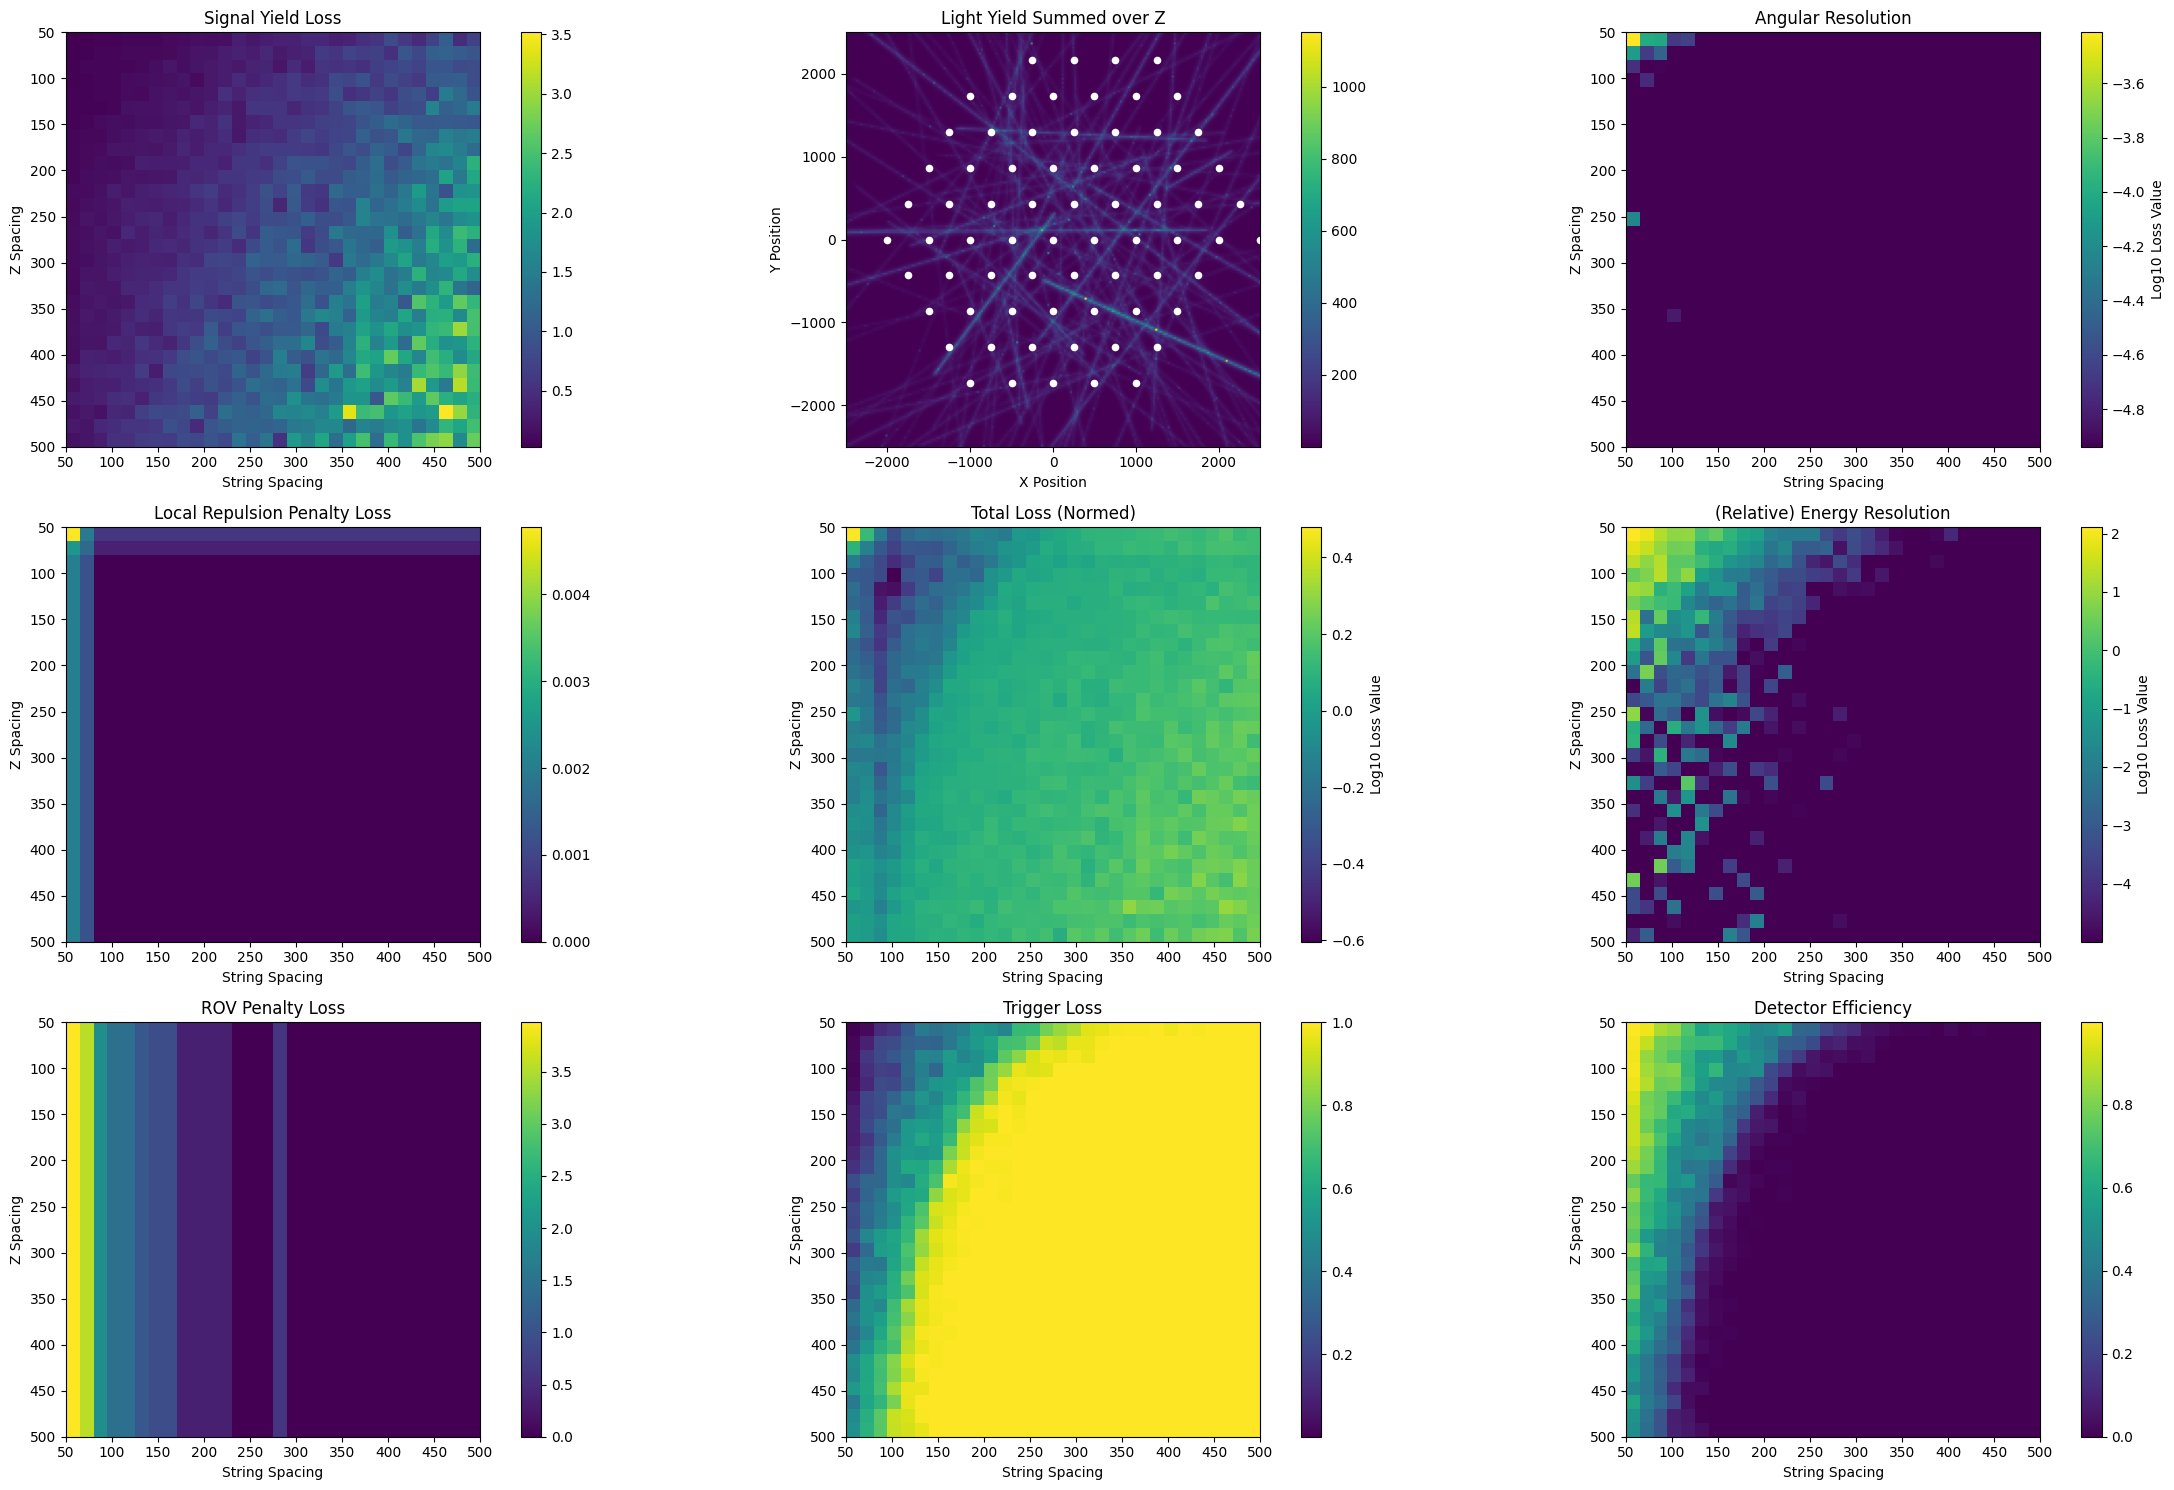

In [38]:
total_loss = signal_yield_losses/np.max(signal_yield_losses) + local_repulsion_penalty_losses/np.max(local_repulsion_penalty_losses) + angular_resolution_losses/np.max(angular_resolution_losses)  + energy_resolution_losses/np.max(energy_resolution_losses) + trigger_losses
#all plots should be binned in logscale, use bins in logspace
fig, axes = plt.subplots(3, 3, figsize=(24, 15))
min_space = 50
max_space = 500
im1 = axes[0, 0].imshow(signal_yield_losses, extent=(min_space, max_space, max_space, min_space))
axes[0, 0].set_title('Signal Yield Loss')
axes[0, 0].set_xlabel('String Spacing')
axes[0, 0].set_ylabel('Z Spacing')
fig.colorbar(im1, ax=axes[0, 0])
# axes[0, 0].set_xscale('log')
# axes[0, 0].set_yscale('log')

# plot the average light yield across z for the 3d grid of points as a contour plot
# first reshape ly to a 40x40x40 array
ly_reshaped = ly.numpy().reshape((steps, steps, steps))
# then take the average across z axis
avg_ly = np.sum(ly_reshaped, axis=2)
im2 = axes[0, 1].imshow(avg_ly, extent=(-xy_half_size, xy_half_size, -xy_half_size, xy_half_size), cmap='viridis')
# plot here also the xy points from geom_dict
axes[0, 1].scatter(geom_dict['string_xy'][:, 0], geom_dict['string_xy'][:, 1], c='white', s=20)
axes[0, 1].set_title('Light Yield Summed over Z')
axes[0, 1].set_xlabel('X Position')
axes[0, 1].set_ylabel('Y Position')
fig.colorbar(im2, ax=axes[0, 1])

im3 = axes[1, 0].imshow(local_repulsion_penalty_losses, extent=(min_space, max_space, max_space, min_space))
axes[1, 0].set_title('Local Repulsion Penalty Loss')
axes[1, 0].set_xlabel('String Spacing')
axes[1, 0].set_ylabel('Z Spacing')
fig.colorbar(im3, ax=axes[1, 0])
# axes[1, 0].set_xscale('log')
# axes[1, 0].set_yscale('log')
im4 = axes[1, 1].imshow(np.log10(total_loss), extent=(min_space, max_space, max_space, min_space))
axes[1, 1].set_title('Total Loss (Normed)')
axes[1, 1].set_xlabel('String Spacing')
axes[1, 1].set_ylabel('Z Spacing')
fig.colorbar(im4, ax=axes[1, 1])
im5 = axes[1, 2].imshow(np.log10(energy_resolution_losses), extent=(min_space, max_space, max_space, min_space))
axes[1, 2].set_title('(Relative) Energy Resolution')
axes[1, 2].set_xlabel('String Spacing')
axes[1, 2].set_ylabel('Z Spacing')
fig.colorbar(im5, ax=axes[1, 2])
# axes[1, 2].set_xscale('log')
# axes[1, 2].set_yscale('log')
im6 = axes[0, 2].imshow(np.log10(angular_resolution_losses), extent=(min_space, max_space, max_space, min_space))
axes[0, 2].set_title('Angular Resolution')
axes[0, 2].set_xlabel('String Spacing')
axes[0, 2].set_ylabel('Z Spacing')
fig.colorbar(im6, ax=axes[0, 2])
#label the colorbars with 'Log10 Loss Value'
# im1.colorbar.set_label('Log10 Loss Value')
# im2.colorbar.set_label('Log10 Loss Value')
# im3.colorbar.set_label('Log10 Loss Value')
im7 = axes[2, 1].imshow(trigger_losses, extent=(min_space, max_space, max_space, min_space))
axes[2, 1].set_title('Trigger Loss')
axes[2, 1].set_xlabel('String Spacing')
axes[2, 1].set_ylabel('Z Spacing')
fig.colorbar(im7, ax=axes[2, 1])
im8 = axes[2, 0].imshow(rov_penalty_losses, extent=(min_space, max_space, max_space, min_space))
axes[2, 0].set_title('ROV Penalty Loss')
axes[2, 0].set_xlabel('String Spacing')
axes[2, 0].set_ylabel('Z Spacing')
fig.colorbar(im8, ax=axes[2, 0])

im4.colorbar.set_label('Log10 Loss Value')
im5.colorbar.set_label('Log10 Loss Value')
im6.colorbar.set_label('Log10 Loss Value')

im9 = axes[2, 2].imshow(detector_efficiencies, extent=(min_space, max_space, max_space, min_space))
axes[2, 2].set_title('Detector Efficiency')
axes[2, 2].set_xlabel('String Spacing')
axes[2, 2].set_ylabel('Z Spacing')
fig.colorbar(im9, ax=axes[2, 2])

# axes[0, 2].set_xscale('log')
# axes[0, 2].set_yscale('log')
# axes[1, 2].remove()

plt.tight_layout()
plt.show()
fig.savefig('loss_landscape_100_event_efficiency_lightsabre_1e6.png')

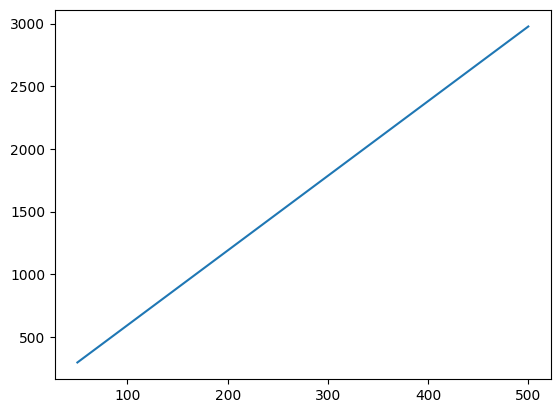

In [39]:
plt.plot(np.linspace(min_space, max_space, test_num), radii[:30])

In [2]:

def likelihood_scan_poisson(
    fisher_info_params,
    points_3d,
    true_event_params,
    surrogate_func,
    param_ranges,
    n_grid_points=50,
    llr_net=None,
    signal_noise_scale=None,
    add_relative_pos=False,
    device=None,
    fixed_test_vals=None,
):
    """
    Perform a likelihood scan over parameter space assuming Poisson-distributed observations.
    
    Parameters:
    -----------
    fisher_info_params : list of str
        List of parameters to scan over (e.g., ['energy'])
    points_3d : torch.Tensor
        Detector points where observations are made
    true_event_params : dict
        True event parameters used to generate observed data
    surrogate_func : callable
        Function that computes expected light yield
    param_ranges : dict
        Dictionary with parameter names as keys and (min, max) tuples as values
        e.g., {'energy': (0.5, 2.0)}
    n_grid_points : int
        Number of grid points for each parameter
    llr_net : optional
        LLR network for predictions
    signal_noise_scale : optional
        Noise scale for signal
    add_relative_pos : bool
        Whether to add relative positions
    device : torch.device
        Device for computations
        
    Returns:
    --------
    dict containing:
        - 'grid_params': parameter grid values
        - 'log_likelihoods': log-likelihood values at each grid point
        - 'observed_counts': observed photon counts at each detector point
        - 'mle_params': maximum likelihood parameter estimates
        - 'true_params': true parameter values
    """
    if device is None:
        device = points_3d.device
    
    # Generate observed data from true parameters
    if llr_net is None:
        lambda_true = surrogate_func(opt_point=points_3d, event_params=true_event_params)
        if signal_noise_scale is not None:
            lambda_true = torch.normal(0, signal_noise_scale) * lambda_true + lambda_true
    else:
        features = llr_net.prepare_data_from_raw(
            points_3d, true_event_params, surrogate_func,
            noise_scale=signal_noise_scale, add_relative_pos=add_relative_pos
        )
        lambda_true = torch.exp(llr_net.predict_log_likelihood_ratio(features, epsilon=1e-9))
    
    # Sample from Poisson distribution
    # observed_counts = torch.poisson(lambda_true.detach())
    observed_counts = lambda_true.detach()
    
    # Create parameter grid
    if len(fisher_info_params) == 1:
        # 1D scan
        param_name = fisher_info_params[0]
        param_min, param_max = param_ranges[param_name]
        grid_values = torch.linspace(param_min, param_max, n_grid_points, device=device)
        
        log_likelihoods = []
        
        for param_value in grid_values:
            # Create hypothesis parameters
            hyp_params = true_event_params.copy()
            if fixed_test_vals is not None:
                for key in fixed_test_vals:
                    hyp_params[key] = fixed_test_vals[key]
            hyp_params[param_name] = param_value
            
            # Compute expected counts for this hypothesis
            if llr_net is None:
                lambda_hyp = surrogate_func(opt_point=points_3d, event_params=hyp_params)
                if signal_noise_scale is not None:
                    lambda_hyp = torch.normal(0, signal_noise_scale) * lambda_hyp + lambda_hyp
            else:
                features = llr_net.prepare_data_from_raw(
                    points_3d, hyp_params, surrogate_func,
                    noise_scale=signal_noise_scale, add_relative_pos=add_relative_pos
                )
                lambda_hyp = torch.exp(llr_net.predict_log_likelihood_ratio(features, epsilon=1e-9))
                
            # Poisson log-likelihood: k*log(λ) - λ - log(k!)
            # Vectorized computation
            log_likelihood = torch.sum(
                observed_counts * torch.log(lambda_hyp) - lambda_hyp - torch.lgamma(observed_counts + 1)
            )
            log_likelihoods.append(log_likelihood.item())
        
        log_likelihoods = torch.tensor(log_likelihoods, device=device)
        
        # Find MLE
        mle_idx = torch.argmax(log_likelihoods)
        mle_params = {param_name: grid_values[mle_idx].item()}
        
        return {
            'grid_params': {param_name: grid_values.cpu().numpy()},
            'log_likelihoods': log_likelihoods.cpu().numpy(),
            'observed_counts': observed_counts.cpu().numpy(),
            'mle_params': mle_params,
            'true_params': true_event_params
        }
    
    elif len(fisher_info_params) == 2:
        # 2D scan
        param1, param2 = fisher_info_params
        param1_min, param1_max = param_ranges[param1]
        param2_min, param2_max = param_ranges[param2]
        
        grid1 = torch.linspace(param1_min, param1_max, n_grid_points, device=device)
        grid2 = torch.linspace(param2_min, param2_max, n_grid_points, device=device)
        
        log_likelihoods = torch.zeros(n_grid_points, n_grid_points, device=device)
        
        for i, val1 in enumerate(grid1):
            for j, val2 in enumerate(grid2):
                hyp_params = true_event_params.copy()
                if fixed_test_vals is not None:
                    for key in fixed_test_vals:
                        hyp_params[key] = fixed_test_vals[key]
                hyp_params[param1] = val1
                hyp_params[param2] = val2
                
                if llr_net is None:
                    lambda_hyp = surrogate_func(opt_point=points_3d, event_params=hyp_params)
                    if signal_noise_scale is not None:
                        lambda_hyp = torch.normal(0, signal_noise_scale) * lambda_hyp + lambda_hyp
                else:
                    features = llr_net.prepare_data_from_raw(
                        points_3d, hyp_params, surrogate_func,
                        noise_scale=signal_noise_scale, add_relative_pos=add_relative_pos
                    )
                    lambda_hyp = torch.exp(llr_net.predict_log_likelihood_ratio(features, epsilon=1e-9))
                
                # Vectorized Poisson log-likelihood computation 
                # Using torch.lgamma(k+1) instead of log(k!) for numerical stability
                log_likelihood = torch.sum(
                    observed_counts * torch.log(lambda_hyp) - lambda_hyp - torch.lgamma(observed_counts + 1)
                )
                log_likelihoods[i, j] = log_likelihood
        
        # Find MLE
        mle_flat_idx = torch.argmax(log_likelihoods)
        mle_i = mle_flat_idx // n_grid_points
        mle_j = mle_flat_idx % n_grid_points
        mle_params = {
            param1: grid1[mle_i].item(),
            param2: grid2[mle_j].item()
        }
        
        return {
            'grid_params': {
                param1: grid1.cpu().numpy(),
                param2: grid2.cpu().numpy()
            },
            'log_likelihoods': log_likelihoods.cpu().numpy(),
            'observed_counts': observed_counts.cpu().numpy(),
            'mle_params': mle_params,
            'true_params': true_event_params
        }
    
    else:
        raise NotImplementedError("Likelihood scan only implemented for 1D or 2D parameter spaces")

/tmp/ipykernel_2461693/2353064681.py:15: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  ly += light_yield_surrogate(opt_point=points, event_params=event_params).numpy()


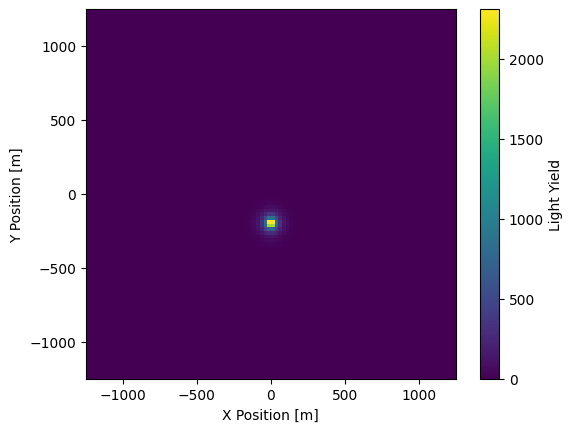

In [4]:
new_signal_events = [{'energy': torch.tensor(10), 'azimuth': torch.tensor(torch.pi), 'zenith': torch.tensor(torch.pi), 'position': torch.tensor([0, 200.0, 0.0])}]
domain_size = 2500
half_size = domain_size / 2
steps = 100
x = np.linspace(-half_size, half_size, steps)
y = np.linspace(-half_size, half_size, steps)
z = np.linspace(-half_size, half_size, steps)
X, Y, Z = np.meshgrid(x, y, z)
points = np.vstack([X.ravel(), Y.ravel(), Z.ravel()]).T
points = torch.tensor(points, dtype=torch.float32)
ly = torch.zeros((points.shape[0],))
for event_params in new_signal_events:
    # event_params['energy'] = torch.tensor([1e6])
    # event_params['zenith'] = torch.tensor([torch.pi / 2])
    ly += light_yield_surrogate(opt_point=points, event_params=event_params).numpy()
ly = ly / len(new_signal_events)
ly_reshaped = ly.numpy().reshape((steps, steps, steps))
# then take the average across z axis
avg_ly = np.sum(ly_reshaped, axis=2)
plt.imshow(avg_ly, extent=(-half_size, half_size, -half_size, half_size), cmap='viridis')
plt.xlabel('X Position [m]')
plt.ylabel('Y Position [m]')
plt.colorbar(label='Light Yield')

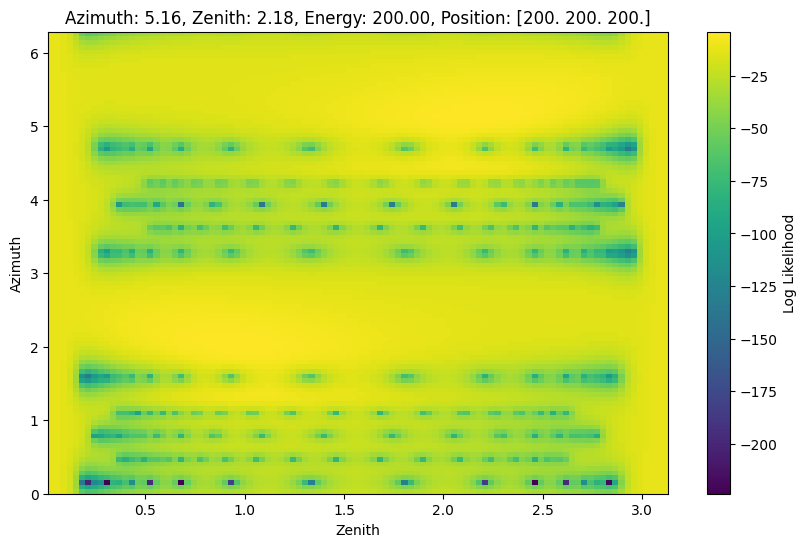

In [8]:
geometry = nugget.geometries.SpaceString.SpaceString(
            hex_type='hexagonal',
            domain_size=2500,  # Size of detector domain
            # device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'),  # Use GPU if available
            dim=3,  # 3D geometry
            n_strings=5,  # Initial number of detector strings
            points_per_string=20,  # Number of PMTs/sensors per string
            # starting_weight=-0.5,  # Initial weight for each string (controls visibility)
            # custom_string_spacing=0.09  # Custom spacing between strings
            starting_spacing=200,
            starting_z_spacing=100
        )
true_event_params={'energy': torch.tensor(200), 'azimuth': torch.rand(1)*2*torch.pi, 'zenith': torch.rand(1)*torch.pi, 'position': torch.tensor([200, 200.0, 200.0])}
geom_dict = geometry.initialize_points()
points_3d = geom_dict['points_3d']
scan_result = likelihood_scan_poisson(
    fisher_info_params=['azimuth', 'zenith'],
    points_3d=points_3d,
    true_event_params=true_event_params,
    surrogate_func=light_yield_surrogate,
    param_ranges={'azimuth': (0.01, 2*torch.pi-0.01), 'zenith': (0.02, torch.pi-0.02)},
    fixed_test_vals= {'energy': true_event_params['energy'], 'position': true_event_params['position']},
    n_grid_points=100
)

# Plot the likelihood curve
plt.figure(figsize=(10, 6))
aximuths = scan_result['grid_params']['azimuth']
zeniths = scan_result['grid_params']['zenith']
log_likelihoods = scan_result['log_likelihoods']
# log_likelihoods = torch.clamp(torch.tensor(log_likelihoods), min=-5, max=0).numpy()
plt.imshow(log_likelihoods, extent=(0.01, np.pi-0.01, 0, 2*np.pi), aspect='auto', origin='lower')
plt.colorbar(label='Log Likelihood')
plt.xlabel('Zenith')  # Now x-axis is zenith
plt.ylabel('Azimuth')  # Now y-axis is azimuth
plt.title(f'Azimuth: {scan_result["true_params"]["azimuth"].item():.2f}, Zenith: {scan_result["true_params"]["zenith"].item():.2f}, Energy: {scan_result["true_params"]["energy"]:.2f}, Position: {scan_result["true_params"]["position"].numpy()}')
plt.show()

In [10]:
light_yield = light_yield_surrogate(opt_point=points_3d, event_params=true_event_params).numpy()
df = pd.DataFrame(points_3d.cpu().numpy(), columns=['x', 'y', 'z'])
df['light_yield'] = light_yield
# df['light_yield'] = np.log10(light_yield)
df['light_yield'][df['light_yield'] < 0] = 0
df['size'] = 10*light_yield/light_yield 
# plot the points and then overlay these with the same points but scaled with light yield, the initial points should be small and grey, the overlayed points should be colored with a colorscale according to light yield
fig = px.scatter_3d(df, x='x', y='y', z='z', opacity=0.7, size='size', size_max=7)
fig.add_trace(px.scatter_3d(df, x='x', y='y', z='z', color='light_yield', color_continuous_scale='viridis', size='light_yield', size_max=30).data[0])
fig.show()



/tmp/ipykernel_2461693/32412615.py:5: FutureWarning:

ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


